# PharmaSales Hybrid Model — Perbaikan Pipeline

**Isi notebook:**
1. Feature engineering baru (kalender + rolling STD + log1p target)
2. Diagnosis Ljung-Box pada residual LR
3. Training Hybrid LR + XGBoost dengan grid yang dilonggarkan
4. Plot distribusi residual

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
import seaborn as sns

warnings.filterwarnings("ignore")
print("Libraries loaded OK")

Libraries loaded OK


## 0. Load Data

In [2]:
# Path relatif dari folder notebooks/ (Jupyter kernel berjalan di sini)
DATA_PATH = '../data/raw/pharma-sales/salesdaily.csv'
data = pd.read_csv(DATA_PATH)
categories = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
print("Shape:", data.shape)
data.head()

Shape: (2106, 13)


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


## 1. Tentukan Max Lags via ACF

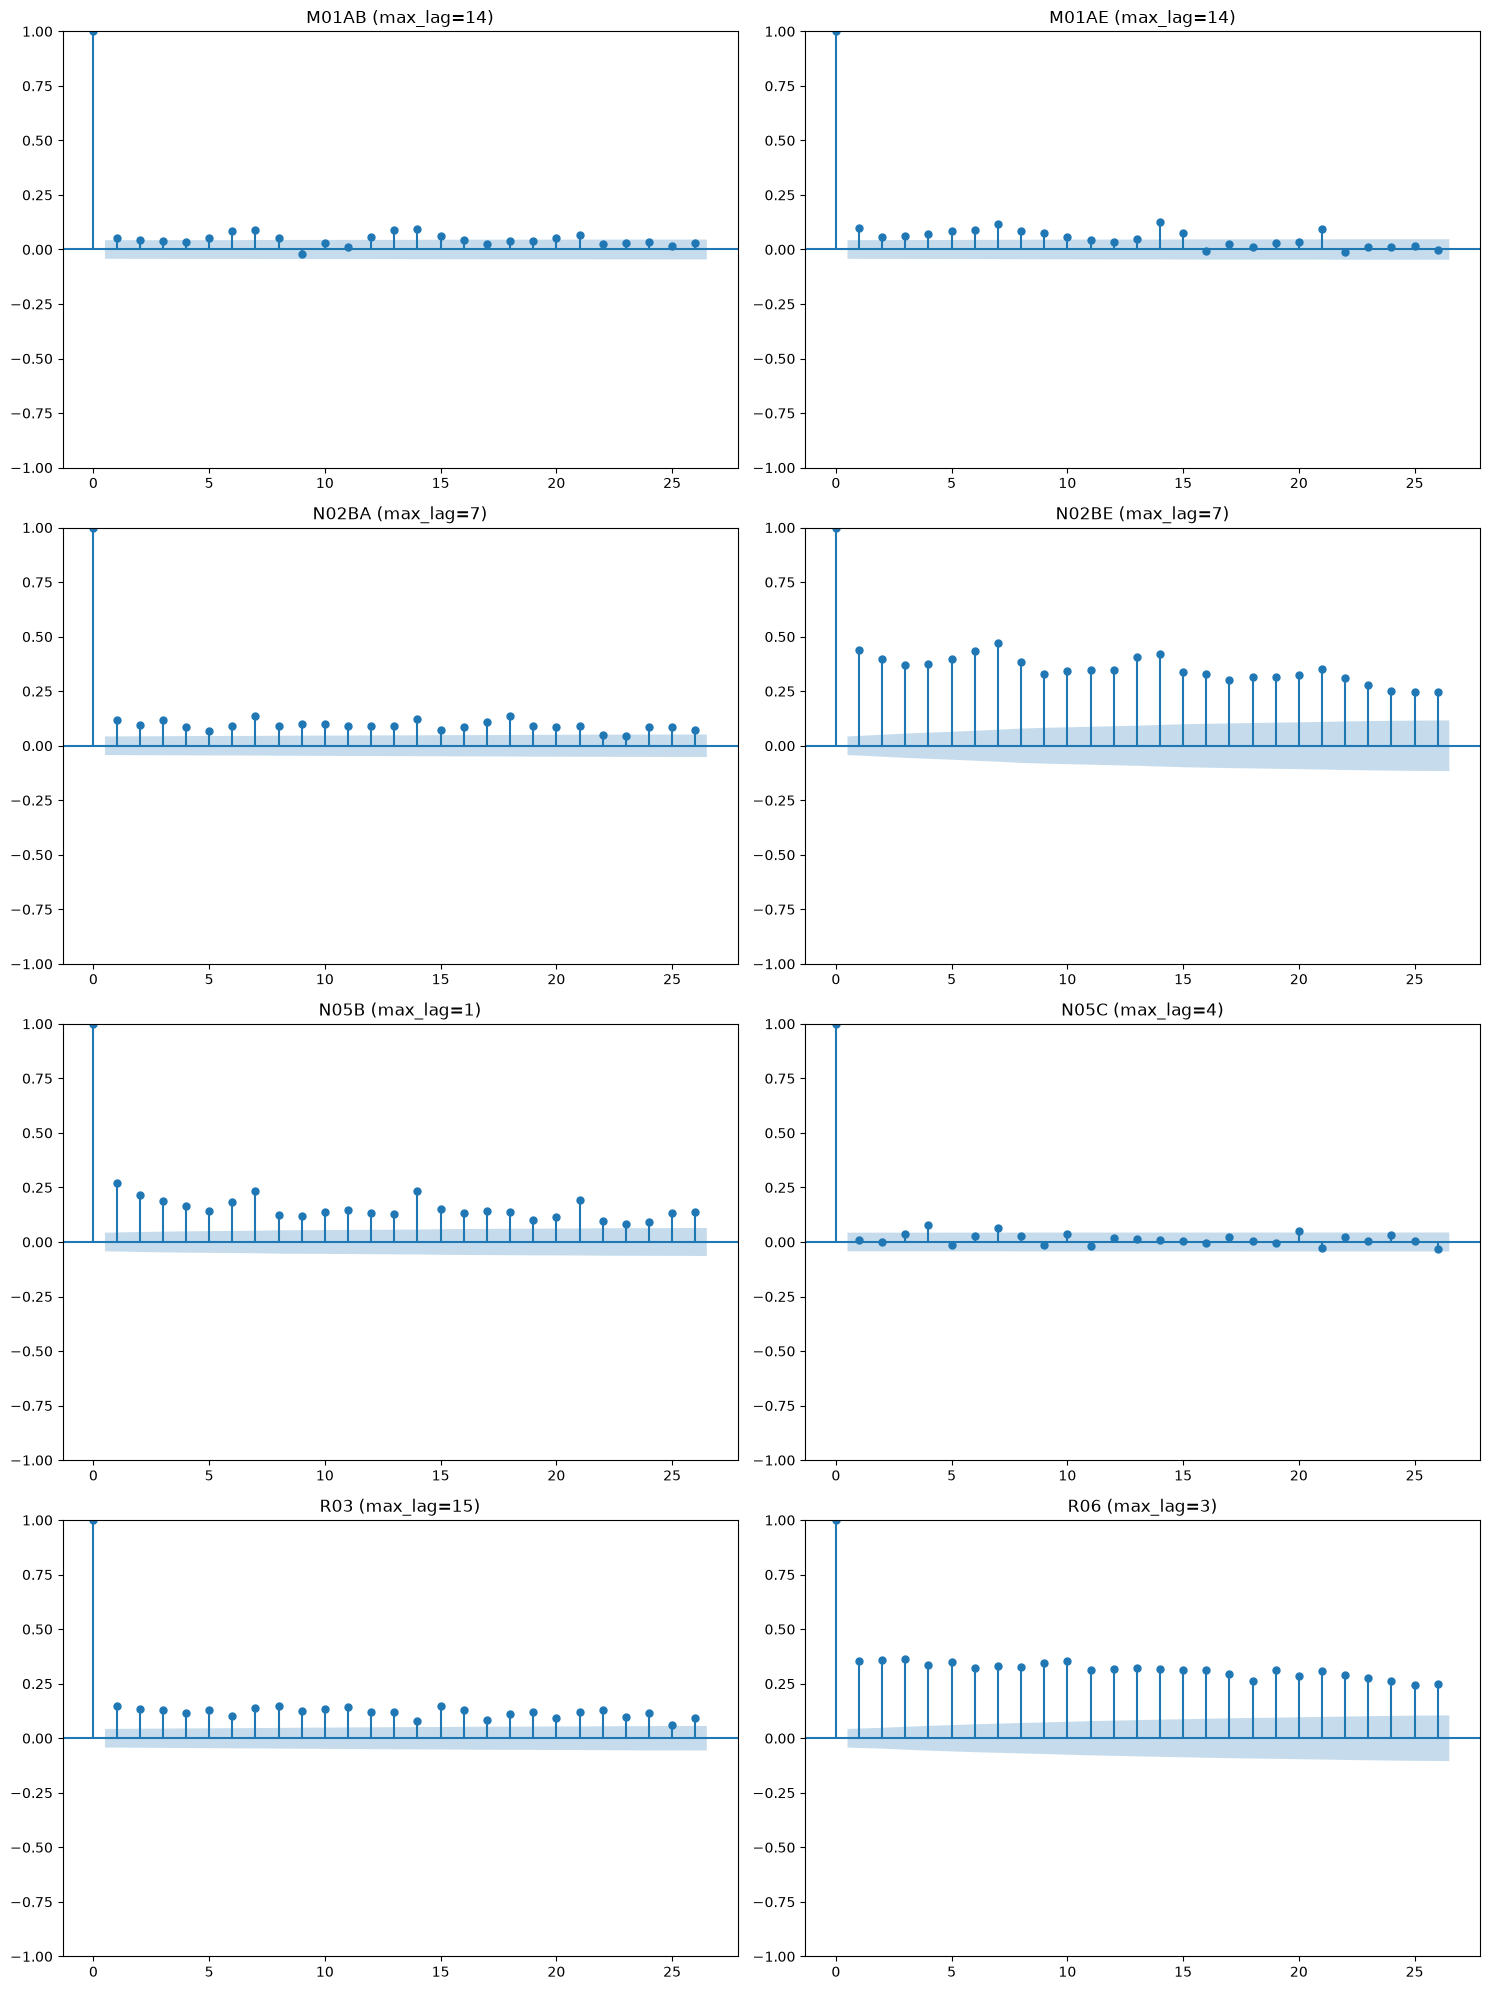

Max lags: {'M01AB': 14, 'M01AE': 14, 'N02BA': 7, 'N02BE': 7, 'N05B': 1, 'N05C': 4, 'R03': 15, 'R06': 3}


In [3]:
max_lags = {}
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, cat in enumerate(categories):
    acf_vals = acf(data[cat], nlags=26)
    max_lags[cat] = int(np.argmax(acf_vals[1:]) + 1)
    plot_acf(data[cat], lags=26, ax=axes[i])
    axes[i].set_title(f"{cat} (max_lag={max_lags[cat]})")

plt.tight_layout()
plt.show()
print("Max lags:", max_lags)

## 2. Feature Engineering Baru

Penambahan dibanding versi sebelumnya:
- **Fitur kalender**: `day_of_week`, `month`, `is_weekend`, `quarter`, `day_of_month`
- **Rolling STD/min/max** dari `y_log` (volatility signal)
- **Lag interaction**: `lag_1 x lag_2` (non-linear signal)
- **Target `log1p(y)`** untuk stabilkan skala residual

In [4]:
dfTransformed = []
drop_cols = ['ds', 'y', 'y_log']

for category in categories:
    dfg = data[['datum', category]].rename(columns={'datum': 'ds', category: 'y'})
    dfg['ds'] = pd.to_datetime(dfg['ds'])

    # [BARU] Transformasi target: log1p
    dfg['y_log'] = np.log1p(dfg['y'])

    # [BARU] Fitur kalender
    dfg['day_of_week']  = dfg['ds'].dt.dayofweek        # 0=Senin, 6=Minggu
    dfg['month']        = dfg['ds'].dt.month             # 1-12
    dfg['is_weekend']   = (dfg['ds'].dt.dayofweek >= 5).astype(int)
    dfg['quarter']      = dfg['ds'].dt.quarter
    dfg['day_of_month'] = dfg['ds'].dt.day
    
    # [BARU] Fitur Fourier — menangkap pola musiman periodik
    dfg['sin_dow']   = np.sin(2 * np.pi * dfg['ds'].dt.dayofweek / 7)
    dfg['cos_dow']   = np.cos(2 * np.pi * dfg['ds'].dt.dayofweek / 7)
    dfg['sin_month'] = np.sin(2 * np.pi * dfg['ds'].dt.month / 12)
    dfg['cos_month'] = np.cos(2 * np.pi * dfg['ds'].dt.month / 12)
    dfg['sin_dom']   = np.sin(2 * np.pi * dfg['ds'].dt.day / 31)
    dfg['cos_dom']   = np.cos(2 * np.pi * dfg['ds'].dt.day / 31)
    
    # Lag dari y_log
    lag_n = max_lags[category]
    for lag in range(1, lag_n + 1):
        dfg[f'lag_{lag}'] = dfg['y_log'].shift(lag)

    # Rolling features
    dfg[f'rolling_mean_{lag_n}'] = dfg['y_log'].shift(1).rolling(lag_n).mean()
    dfg[f'rolling_std_{lag_n}'] = (dfg['y_log'].shift(1)
                                .rolling(lag_n, min_periods=1).std()
                                .fillna(0))
    dfg[f'rolling_min_{lag_n}']  = dfg['y_log'].shift(1).rolling(lag_n).min()   # [BARU]
    dfg[f'rolling_max_{lag_n}']  = dfg['y_log'].shift(1).rolling(lag_n).max()   # [BARU]

    # [BARU] Lag interaction
    if lag_n >= 2:
        dfg['lag1_x_lag2'] = dfg['lag_1'] * dfg['lag_2']

    dfg = dfg.dropna()
    n   = len(dfg)
    tr  = int(n * 0.6)
    vl  = int(n * 0.2)

    dfgtrain = dfg.iloc[:tr]
    dfgval   = dfg.iloc[tr:tr + vl]
    dfgtest  = dfg.iloc[tr + vl:]

    dfTransformed.append({
        "category": category,
        "dfgTest":  dfgtest,
        "data": {
            "X_train": dfgtrain.drop(columns=drop_cols).to_numpy(),
            "y_train": dfgtrain['y_log'].to_numpy(),
            "X_val":   dfgval.drop(columns=drop_cols).to_numpy(),
            "y_val":   dfgval['y_log'].to_numpy(),
            "X_test":  dfgtest.drop(columns=drop_cols).to_numpy(),
            "y_test":  dfgtest['y_log'].to_numpy(),
        }
    })

feat_names = dfTransformed[0]['dfgTest'].drop(columns=drop_cols).columns.tolist()
print(f"Total fitur sekarang: {len(feat_names)}")
print(feat_names)

Total fitur sekarang: 30
['day_of_week', 'month', 'is_weekend', 'quarter', 'day_of_month', 'sin_dow', 'cos_dow', 'sin_month', 'cos_month', 'sin_dom', 'cos_dom', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'lag_14', 'rolling_mean_14', 'rolling_std_14', 'rolling_min_14', 'rolling_max_14', 'lag1_x_lag2']


## 3. Diagnosis: Uji Ljung-Box pada Residual LR

- `p > 0.05` → **white noise** → XGBoost tidak bisa membantu, residual memang sudah acak
- `p < 0.05` → **ada pola** → XGBoost *seharusnya* bisa belajar; masalah ada di fitur/hyperparameter

LJUNG-BOX TEST — Residual Linear Regression (Fitur Baru)
[M01AB]  p(lag10)=0.9999  p(lag20)=0.9968  → WHITE NOISE ✅
[M01AE]  p(lag10)=1.0000  p(lag20)=0.9998  → WHITE NOISE ✅
[N02BA]  p(lag10)=0.9934  p(lag20)=0.9544  → WHITE NOISE ✅
[N02BE]  p(lag10)=0.6910  p(lag20)=0.0021  → ADA POLA ❌
[N05B]  p(lag10)=0.0000  p(lag20)=0.0000  → ADA POLA ❌
[N05C]  p(lag10)=0.9007  p(lag20)=0.7357  → WHITE NOISE ✅
[R03]  p(lag10)=1.0000  p(lag20)=0.9988  → WHITE NOISE ✅
[R06]  p(lag10)=0.7830  p(lag20)=0.3828  → WHITE NOISE ✅


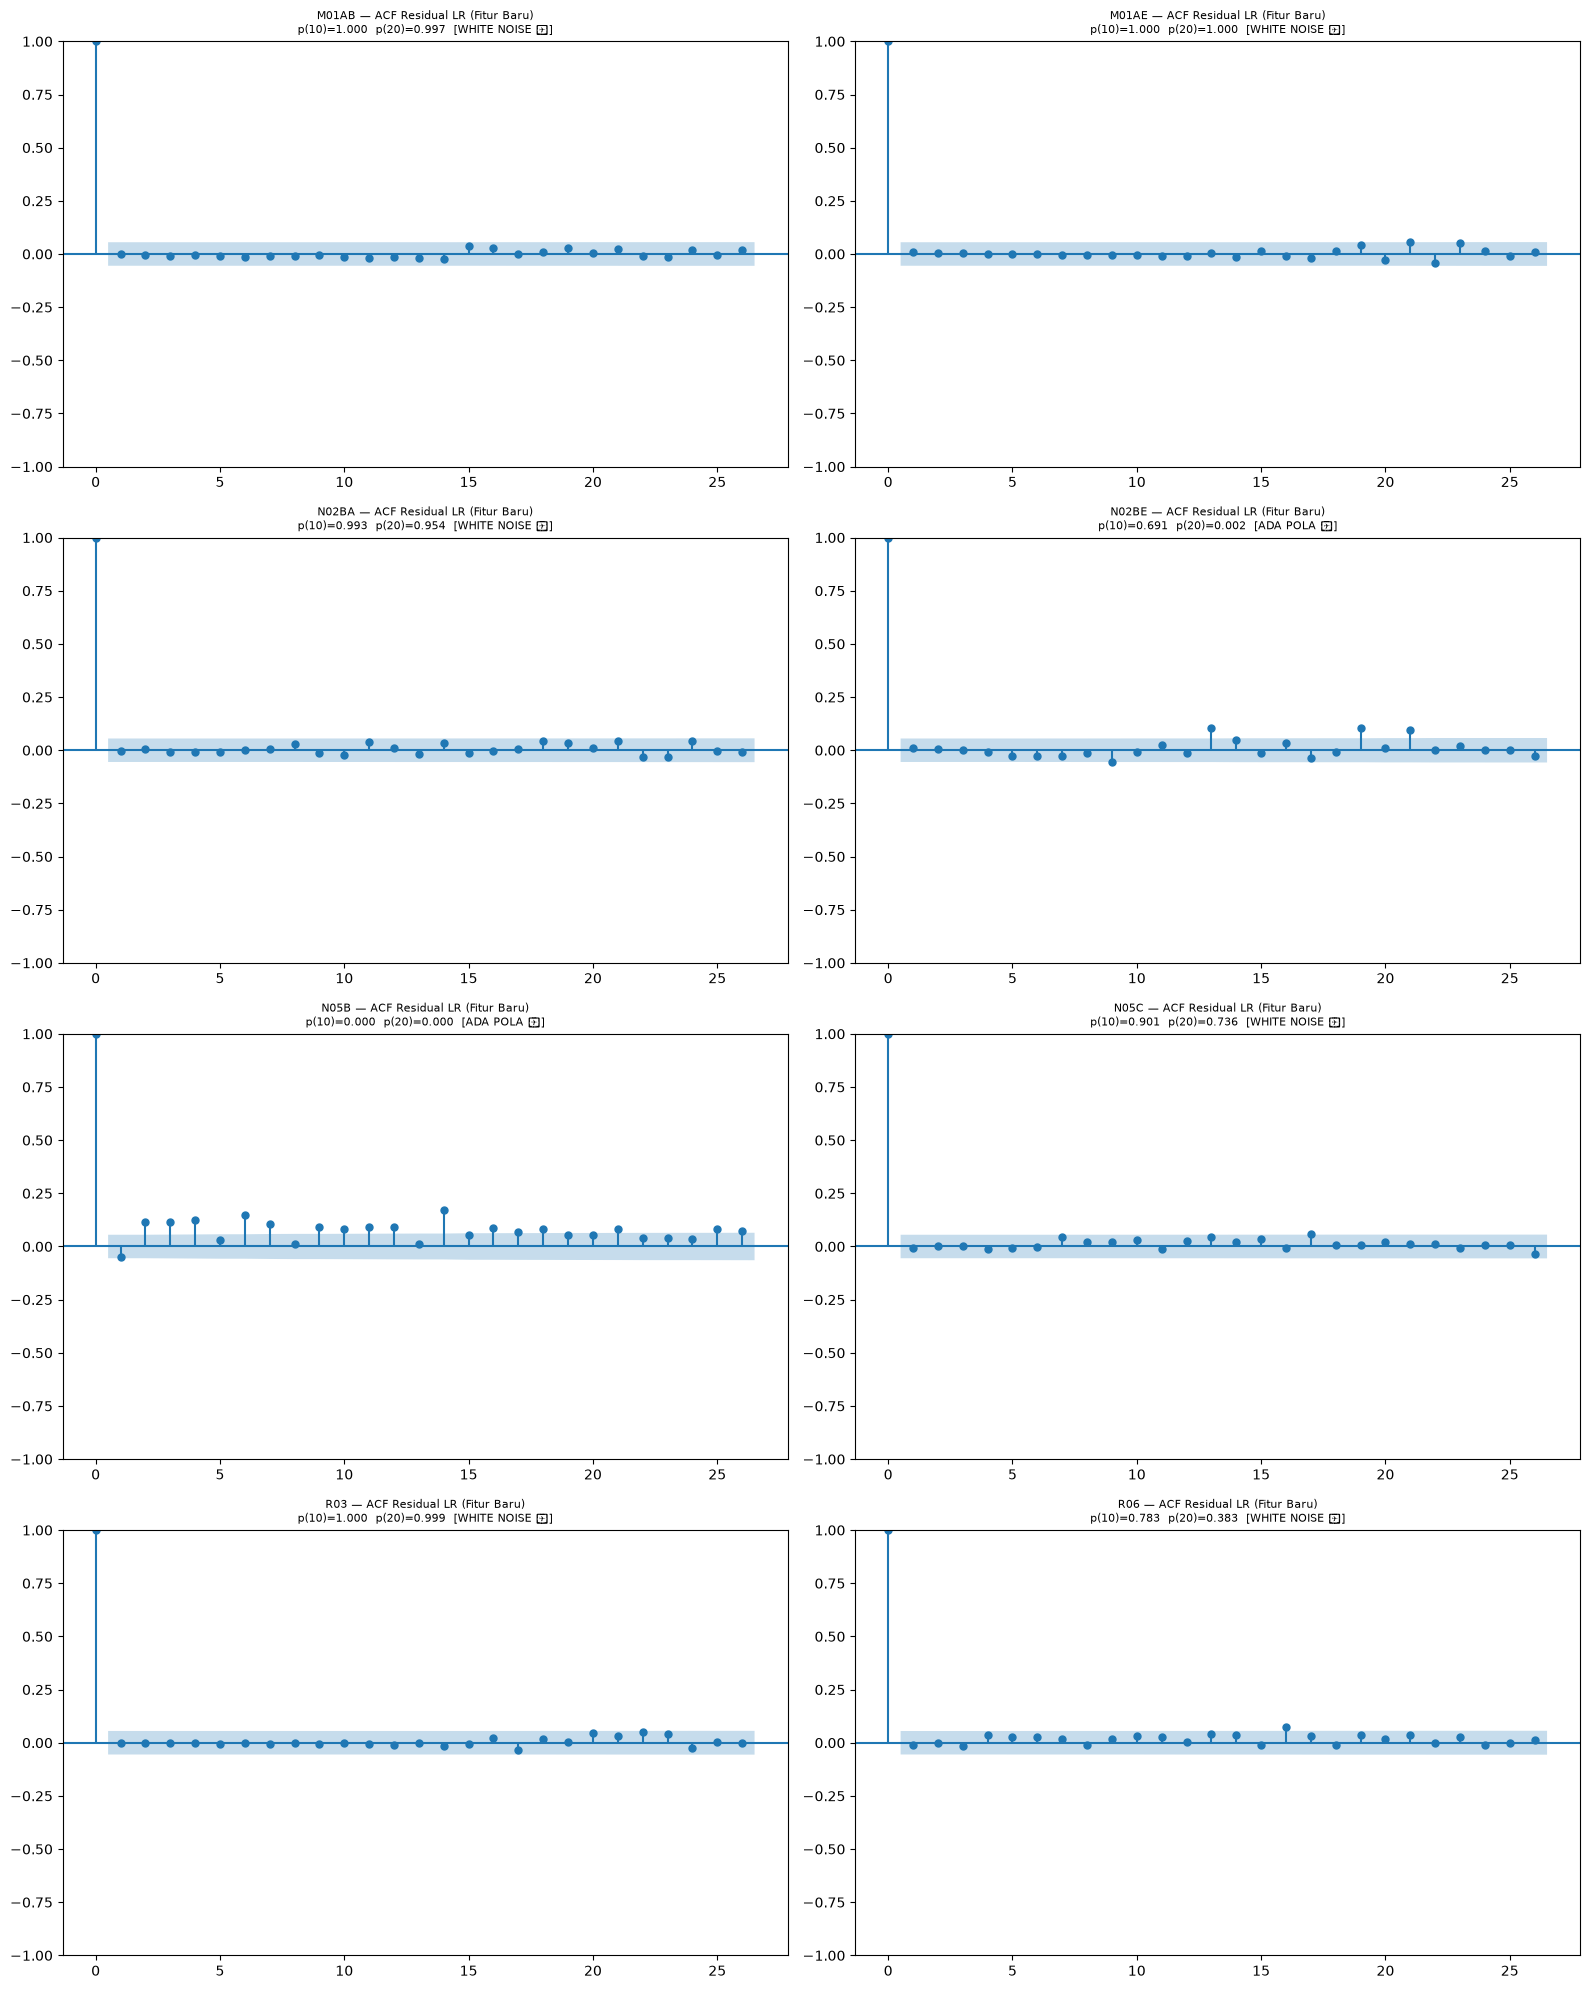

,category,p_lag10,p_lag20,verdict
0,M01AB,0.9999,0.9968,WHITE NOISE ✅
1,M01AE,1.0000,0.9998,WHITE NOISE ✅
2,N02BA,0.9934,0.9544,WHITE NOISE ✅
3,N02BE,0.6910,0.0021,ADA POLA ❌
4,N05B,0.0000,0.0000,ADA POLA ❌
5,N05C,0.9007,0.7357,WHITE NOISE ✅
6,R03,1.0000,0.9988,WHITE NOISE ✅
7,R06,0.7830,0.3828,WHITE NOISE ✅


In [5]:
print("=" * 58)
print("LJUNG-BOX TEST — Residual Linear Regression (Fitur Baru)")
print("=" * 58)

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()
lb_rows = []

for idx, cat_data in enumerate(dfTransformed):
    cat_name = cat_data["category"]
    X_tr     = cat_data["data"]["X_train"]
    y_tr     = cat_data["data"]["y_train"]

    lr        = LinearRegression().fit(X_tr, y_tr)
    residuals = y_tr - lr.predict(X_tr)

    p10 = float(acorr_ljungbox(residuals, lags=[10], return_df=True)["lb_pvalue"].values[0])
    p20 = float(acorr_ljungbox(residuals, lags=[20], return_df=True)["lb_pvalue"].values[0])
    verdict = "WHITE NOISE ✅" if (p10 > 0.05 and p20 > 0.05) else "ADA POLA ❌"

    print(f"[{cat_name}]  p(lag10)={p10:.4f}  p(lag20)={p20:.4f}  → {verdict}")
    lb_rows.append({"category": cat_name, "p_lag10": round(p10,4),
                    "p_lag20": round(p20,4), "verdict": verdict})

    plot_acf(residuals, lags=26, ax=axes[idx], alpha=0.05)
    axes[idx].set_title(
        f"{cat_name} — ACF Residual LR (Fitur Baru)\n"
        f"p(10)={p10:.3f}  p(20)={p20:.3f}  [{verdict}]", fontsize=8
    )

plt.tight_layout()
plt.show()
pd.DataFrame(lb_rows)

## 4. Training Hybrid LR + XGBoost (Residual) — Grid Dilonggarkan

In [6]:
# Override grid khusus per kategori yang bermasalah
param_grid_override = {
    'R03': {
        'n_estimators':     [100, 300, 500],
        'max_depth':        [2, 3],          # lebih dangkal
        'learning_rate':    [0.01, 0.05],
        'subsample':        [0.6, 0.8],
        'colsample_bytree': [0.6, 0.8],
        'min_child_weight': [5, 10],         # lebih ketat
        'min_split_loss': [0.5, 1.0],   # ganti 'gamma' di R03 override
        'reg_lambda':       [5.0, 10.0],     # regularisasi kuat
    }
}

# Grid hyperparameter lebih luas dibanding versi lama

param_grid_residual = {
    'n_estimators':     [100, 300, 500],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'min_child_weight': [1, 3],      # lama hanya [3]
    'gamma':            [0, 0.1],    # lama tidak ada gamma=0
    'reg_lambda':       [0.1, 1.0],  # lama [10.0] terlalu ketat
}

finalResult = []

for cat_data in dfTransformed:
    cat_name = cat_data["category"]
    X_tr = cat_data["data"]["X_train"]
    y_tr = cat_data["data"]["y_train"]
    X_vl = cat_data["data"]["X_val"]
    y_vl = cat_data["data"]["y_val"]
    X_te = cat_data["data"]["X_test"]
    y_te = cat_data["data"]["y_test"]

    X_full = np.vstack([X_tr, X_vl])
    y_full = np.concatenate([y_tr, y_vl])

    # Step 1: LR
    lr            = LinearRegression().fit(X_full, y_full)
    residuals     = y_full - lr.predict(X_full)
    lr_pred_test  = lr.predict(X_te)

    # Step 2: Grid Search XGBoost pada residual
    tscv = TimeSeriesSplit(n_splits=5)
    grid_to_use = param_grid_override.get(cat_name, param_grid_residual)
    gs = GridSearchCV(
        xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        tree_method='hist'
    ),
        grid_to_use,
        scoring='neg_mean_squared_error',
        cv=tscv, n_jobs=-1, verbose=0
    )
    gs.fit(X_full, residuals)
    best = gs.best_params_
    print(f"[{cat_name}] Best params: {best}")

    # Step 3: Latih ulang dengan best params
    xgb_final = xgb.XGBRegressor(
        objective='reg:squarederror', random_state=42,
        n_jobs=-1, tree_method='hist', **best
    ).fit(X_full, residuals)

    hybrid_log   = lr_pred_test + xgb_final.predict(X_te)

    # Step 4: Inverse log1p → skala asli
    y_real       = np.expm1(y_te)
    lr_real      = np.expm1(lr_pred_test)
    hybrid_real  = np.expm1(hybrid_log)

    rmse_lr  = np.sqrt(mean_squared_error(y_real, lr_real))
    rmse_hyb = np.sqrt(mean_squared_error(y_real, hybrid_real))
    impr     = (rmse_lr - rmse_hyb) / rmse_lr * 100

    finalResult.append({"category": cat_name, "rmse_lr": round(rmse_lr,4),
                        "rmse_hybrid": round(rmse_hyb,4),
                        "improvement_%": round(impr,2), **best})

dfResult = pd.DataFrame(finalResult)
dfResult[["category","rmse_lr","rmse_hybrid","improvement_%"]]

[M01AB] Best params: {'colsample_bytree': 0.7, 'gamma': 0.1, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'reg_lambda': 1.0, 'subsample': 0.7}
[M01AE] Best params: {'colsample_bytree': 0.7, 'gamma': 0.1, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'reg_lambda': 1.0, 'subsample': 0.9}
[N02BA] Best params: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'reg_lambda': 1.0, 'subsample': 0.7}
[N02BE] Best params: {'colsample_bytree': 0.9, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 100, 'reg_lambda': 1.0, 'subsample': 0.7}
[N05B] Best params: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'reg_lambda': 1.0, 'subsample': 0.7}
[N05C] Best params: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'min_

,category,rmse_lr,rmse_hybrid,improvement_%
0,M01AB,2.8823,2.8745,0.27
1,M01AE,2.1631,2.1683,-0.24
2,N02BA,1.9880,1.9744,0.68
3,N02BE,12.9368,12.7134,1.73
4,N05B,4.2518,4.2332,0.44
5,N05C,1.1598,1.1604,-0.06
6,R03,8.9185,8.9346,-0.18
7,R06,2.4092,2.3985,0.44


## 5. Plot Distribusi Residual — LR vs Hybrid

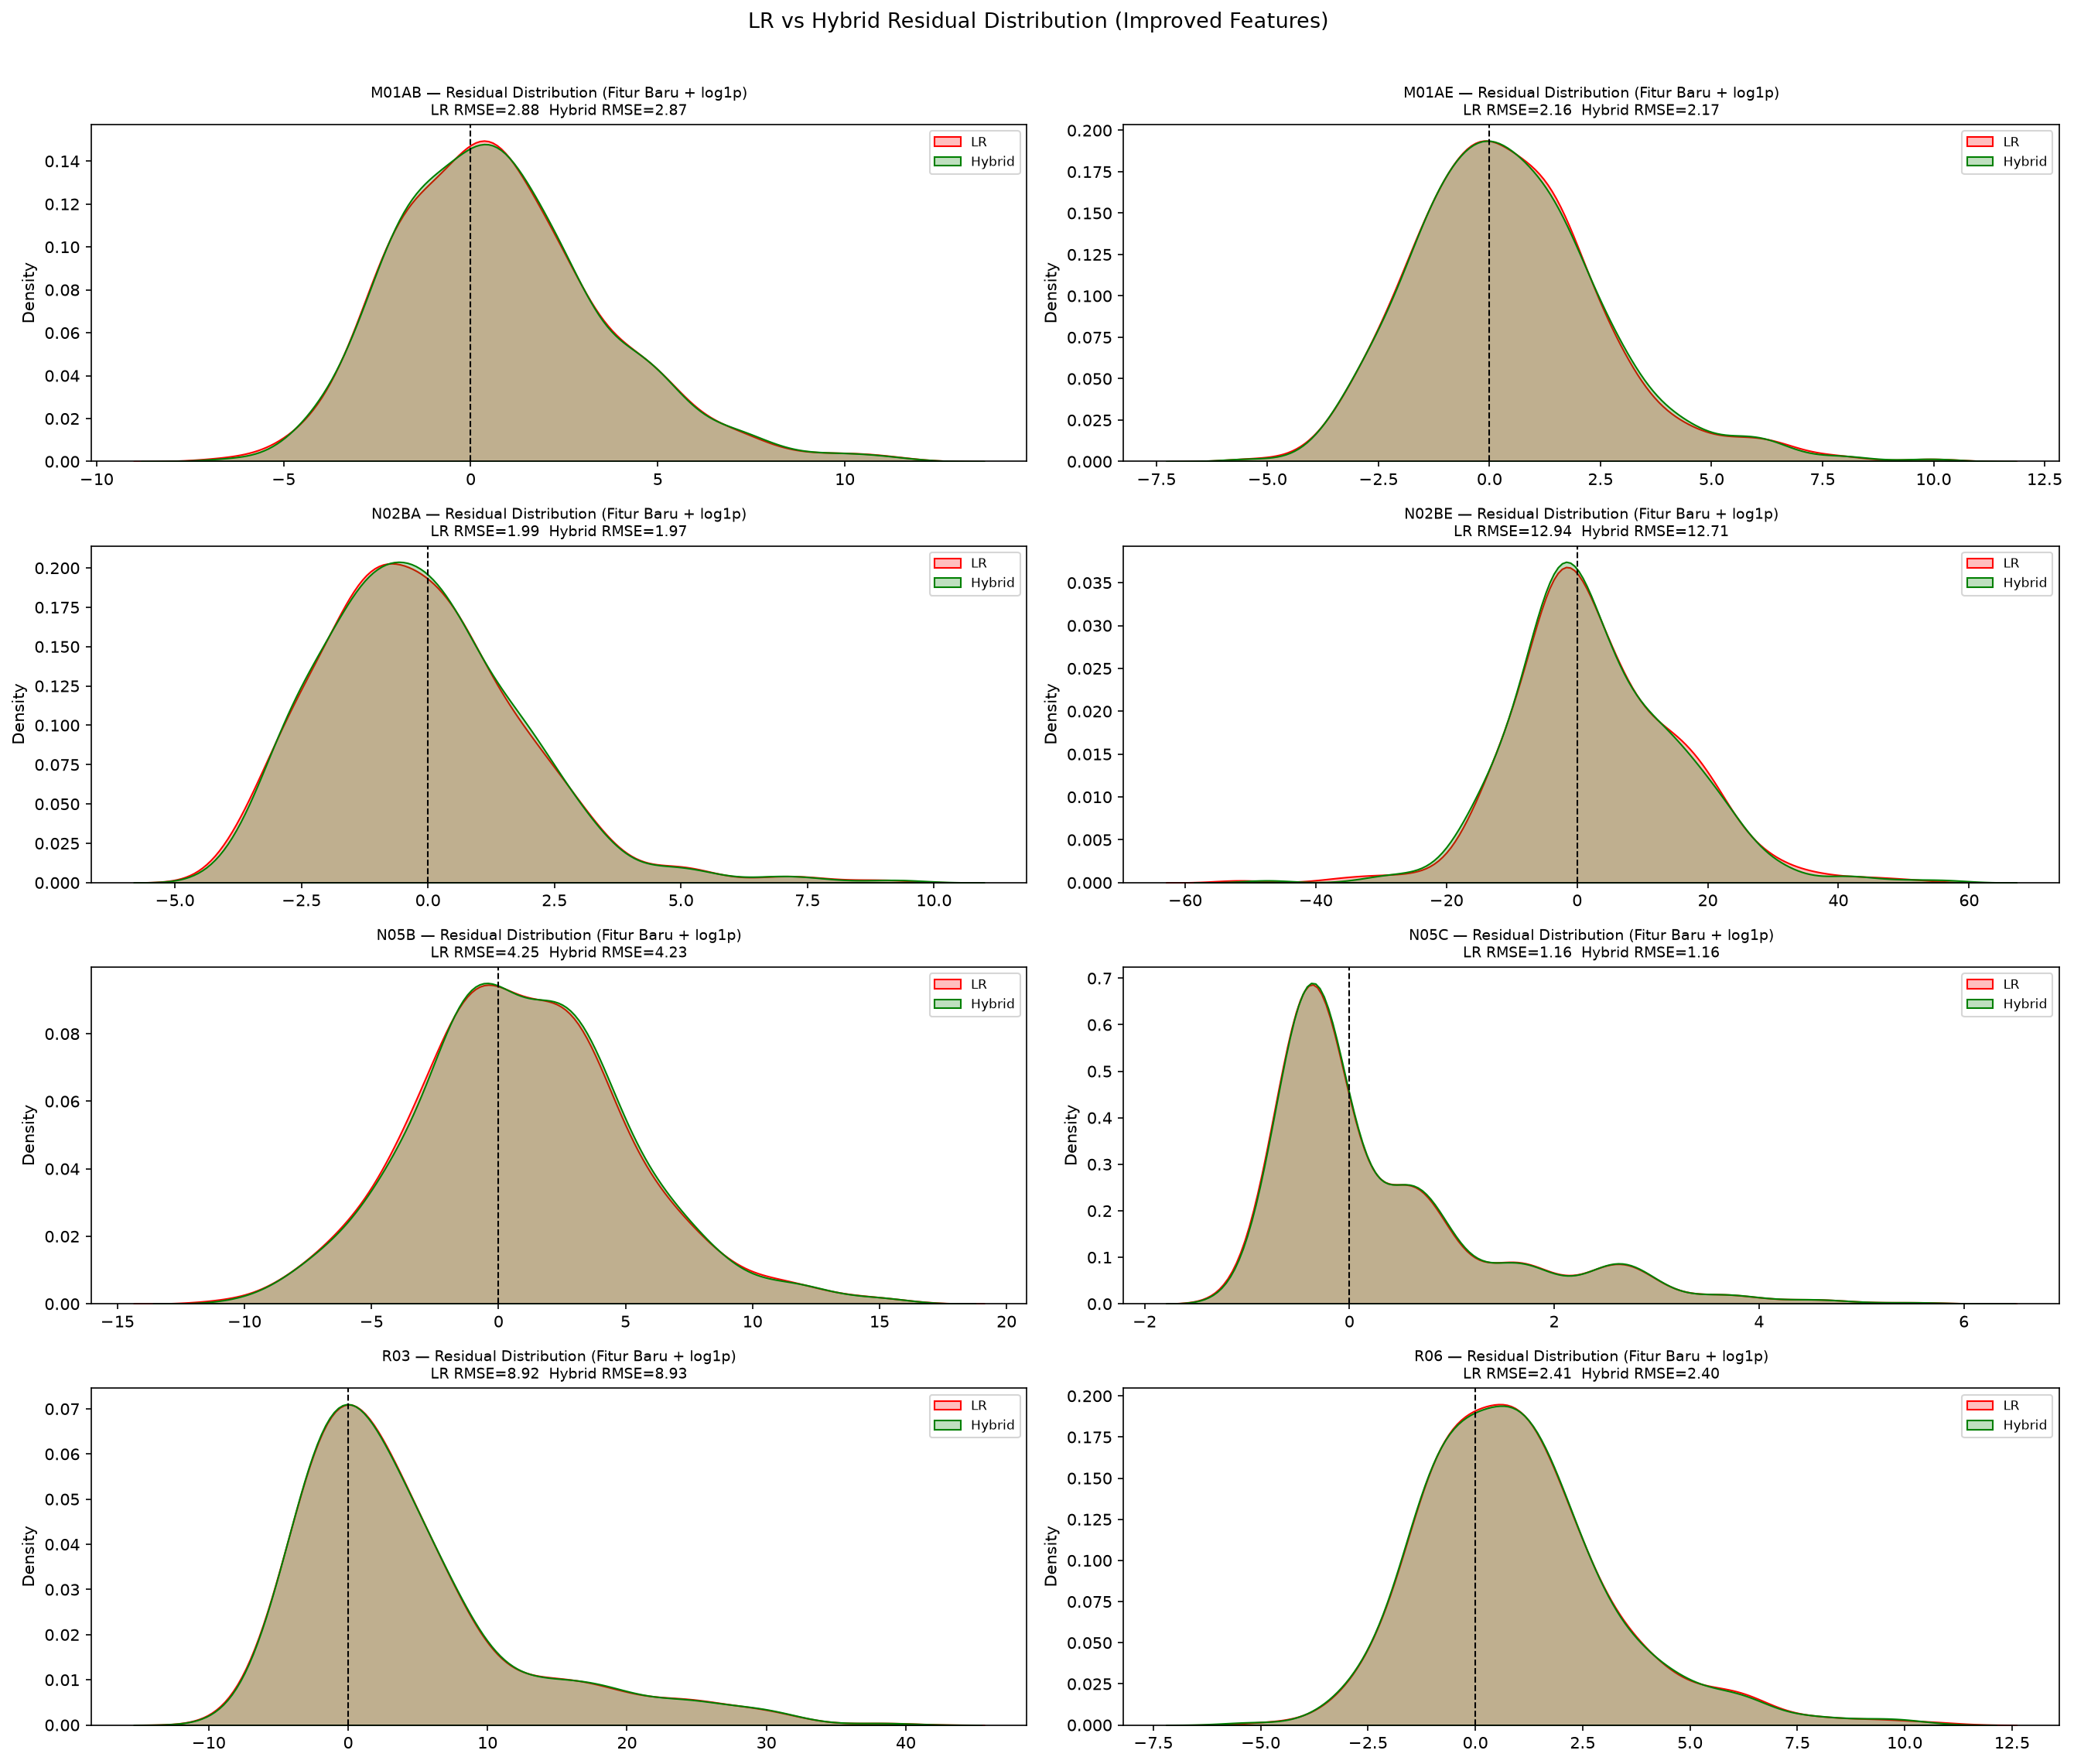

In [7]:
fig, axes = plt.subplots(4, 2, figsize=(18, 15), dpi=150)
axes = axes.flatten()

for idx, cat_data in enumerate(dfTransformed):
    cat_name = cat_data["category"]
    X_tr = cat_data["data"]["X_train"]
    y_tr = cat_data["data"]["y_train"]
    X_vl = cat_data["data"]["X_val"]
    y_vl = cat_data["data"]["y_val"]
    X_te = cat_data["data"]["X_test"]
    y_te = cat_data["data"]["y_test"]

    row       = dfResult[dfResult["category"] == cat_name].iloc[0]
    xgb_keys  = list(param_grid_residual.keys())
    xgb_p     = {k: row[k] for k in xgb_keys if k in row.index}

    X_full = np.vstack([X_tr, X_vl])
    y_full = np.concatenate([y_tr, y_vl])

    lr           = LinearRegression().fit(X_full, y_full)
    residuals    = y_full - lr.predict(X_full)
    lr_pred_test = lr.predict(X_te)

    xgb_m = xgb.XGBRegressor(
        objective='reg:squarederror', random_state=42,
        n_jobs=-1, tree_method='hist', **xgb_p
    ).fit(X_full, residuals)

    hybrid_log  = lr_pred_test + xgb_m.predict(X_te)
    y_real      = np.expm1(y_te)
    lr_real     = np.expm1(lr_pred_test)
    hybrid_real = np.expm1(hybrid_log)

    rmse_lr  = float(row["rmse_lr"])
    rmse_hyb = float(row["rmse_hybrid"])

    ax = axes[idx]
    sns.kdeplot(y_real - lr_real,     ax=ax, color='red',   label='LR',     fill=True, alpha=0.25)
    sns.kdeplot(y_real - hybrid_real, ax=ax, color='green', label='Hybrid', fill=True, alpha=0.25)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(
        f"{cat_name} — Residual Distribution (Fitur Baru + log1p)\n"
        f"LR RMSE={rmse_lr:.2f}  Hybrid RMSE={rmse_hyb:.2f}", fontsize=9
    )
    ax.legend(fontsize=8)

plt.suptitle("LR vs Hybrid Residual Distribution (Improved Features)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()